# Phase 3 - Use Latent Database

This notebook uses the saved latent database for:

1. loading latent vectors for the full 20k dataset,
2. querying by `simu_index`,
3. nearest-neighbor retrieval,
4. comparing distance metrics,
5. computing latent-space density,
6. relating density to reconstruction error.
7. targeted fine tunning.

## Model / Representation
- CNN AE
- `ln_phase`
- latent dimension = 60

# Cell 1 - Imports and setup

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import pairwise_distances   #for distance computation
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors    #density

# project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)

from Sources.dataset import PDNDataset
from Sources.models import CNNAutoencoder

PROJECT_ROOT: /home/tekb/Master_Thesis_KB/CodesAndData


# Cell 2 - Config

In [2]:
EXPERIMENT_NAME = "use_latent_database_cnn_ln_phase_ld60"

RUN_CFG = {
    "data_dir": "../../Data/variation",
    "csv_file": "../../Data/parameter.csv",
    "repr_name": "ln_phase",
    "latent_dim": 60,
    "batch_size": 256,

    # trained AE checkpoint (same model used to build latent DB)
    "checkpoint_path": "../../checkpoints/cnn_ae_ln_phase_mse_N14000_ld60_lr0.0003_ep500.pt",

    # latent database built in Phase 2
    "latent_npz_path": "../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.npz",
    "latent_csv_path": "../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.csv",
}

RESULTS_DIR = os.path.join("../../Results", EXPERIMENT_NAME)
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print("Results dir      :", RESULTS_DIR)
print("Latent NPZ path  :", RUN_CFG["latent_npz_path"])
print("Latent CSV path  :", RUN_CFG["latent_csv_path"])
print("Checkpoint path  :", RUN_CFG["checkpoint_path"])

Results dir      : ../../Results/use_latent_database_cnn_ln_phase_ld60
Latent NPZ path  : ../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.npz
Latent CSV path  : ../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.csv
Checkpoint path  : ../../checkpoints/cnn_ae_ln_phase_mse_N14000_ld60_lr0.0003_ep500.pt


# Cell 3 - Load latent database

In [3]:
data = np.load(RUN_CFG["latent_npz_path"])
db_df = pd.read_csv(RUN_CFG["latent_csv_path"])

Z = data["latents"]        # [N, 60]
SID = data["simu_ids"]     # [N]
GEO = data["geometry"]     # [N, 17]
freq_hz = data["freq_hz"]  # [334]

print("Loaded latent database")
print("Z shape      :", Z.shape)
print("SID shape    :", SID.shape)
print("GEO shape    :", GEO.shape)
print("freq shape   :", freq_hz.shape)
print("CSV shape    :", db_df.shape)

Loaded latent database
Z shape      : (20000, 60)
SID shape    : (20000,)
GEO shape    : (20000, 17)
freq shape   : (334,)
CSV shape    : (20000, 78)


# Cell 4 - Build simu_index query helpers

In [4]:
# map real simulation id -> row index in database
sid_to_row = {int(sid): i for i, sid in enumerate(SID)}

def get_row_from_sid(query_sid: int) -> int:
    query_sid = int(query_sid)
    if query_sid not in sid_to_row:
        raise ValueError(f"simu_index {query_sid} not found in latent database")
    return sid_to_row[query_sid]

def get_sid_from_row(row_idx: int) -> int:
    return int(SID[row_idx])

print("Helper maps ready.")
print("Example: first SID =", int(SID[0]), "| row =", get_row_from_sid(int(SID[0])))

Helper maps ready.
Example: first SID = 100000 | row = 0


# Cell 5 - Load geometry column names from CSV

In [5]:
param_df = pd.read_csv(RUN_CFG["csv_file"])
geo_columns = param_df.columns.drop("simu_index").tolist()

print("Geometry columns:", len(geo_columns))
print(geo_columns)

Geometry columns: 17
['TDIEL', 'TMET', 'XWIDTH', 'YWIDTH', 'CONDUCTIVITY', 'PERMITTIVITY', 'LOSSTANGENT', 'A1_VIARADIUS', 'A1_ANTIPADRADIUS', 'A1_VIAPITCH', 'A1_XCENTER', 'A1_YCENTER', 'A2_VIARADIUS', 'A2_ANTIPADRADIUS', 'A2_VIAPITCH', 'A2_XCENTER', 'A2_YCENTER']


# Cell 6 - Distance metric helpers

In [6]:
def get_latent_matrix(metric="euclidean"):
    """
    Returns latent matrix to be used for distance computation.

    metric_mode:
      - 'euclidean'   -> raw Z
      - 'cosine'      -> raw Z, cosine distance computed later
      - 'normalized'  -> z-score normalized latent dimensions
    """
    if metric == "normalized":
        scaler = StandardScaler()
        Z_used = scaler.fit_transform(Z)
        return Z_used
    elif metric in ["euclidean", "cosine"]:
        return Z.copy()
    else:
        raise ValueError("metric must be 'euclidean', 'cosine', or 'normalized'")


def nearest_neighbors_by_sid(query_sid, k=5, metric="euclidean"):
    """
    Query nearest neighbors using real simu_index.

    Returns:
        query_row, nn_rows, nn_sids, nn_dist
    """
    query_row = get_row_from_sid(query_sid)
    Z_used = get_latent_matrix(metric=metric)

    # distance from query row to all rows
    if metric == "cosine":
        d = pairwise_distances(
            Z_used[query_row:query_row+1],
            Z_used,
            metric="cosine"
        ).ravel()

    else:
        # euclidean or normalized
        d = pairwise_distances(
            Z_used[query_row:query_row+1],
            Z_used,
            metric="euclidean"
        ).ravel()

    # sort distances, skip self
    nn_rows = np.argsort(d)[1:k+1]
    nn_sids = SID[nn_rows].astype(int)
    nn_dist = d[nn_rows]

    return query_row, nn_rows, nn_sids, nn_dist

# Cell 7 - Run one nearest-neighbor query by simu_index

In [7]:
query_sid = 100328
k = 5
metric = "euclidean"   # options: euclidean, cosine, normalized

query_row, nn_rows, nn_sids, nn_dist = nearest_neighbors_by_sid(
    query_sid=query_sid,
    k=k,
    metric=metric
)

print("Query")
print("  simu_index :", query_sid)
print("  row index  :", query_row)
print("  metric     :", metric)

print("\nNearest neighbors")
for r, sid, dist in zip(nn_rows, nn_sids, nn_dist):
    print(f"  row={int(r):5d} | SID={int(sid)} | distance={float(dist):.6f}")

Query
  simu_index : 100328
  row index  : 328
  metric     : euclidean

Nearest neighbors
  row= 9003 | SID=109003 | distance=5.317965
  row= 4423 | SID=104423 | distance=5.361255
  row= 8867 | SID=108867 | distance=5.381074
  row=10381 | SID=110381 | distance=5.835713
  row=15227 | SID=115227 | distance=6.023512


# Cell 8 - Show query + neighbor geometry

In [8]:
def show_query_and_neighbor_geometry(query_sid, nn_sids, geo_columns, max_cols=None):
    cols = ["simu_index"] + geo_columns
    if max_cols is not None:
        cols = ["simu_index"] + geo_columns[:max_cols]

    rows = [get_row_from_sid(query_sid)] + [get_row_from_sid(sid) for sid in nn_sids]
    sub = db_df.iloc[rows][cols].copy().reset_index(drop=True)

    labels = ["QUERY"] + [f"NN_{i+1}" for i in range(len(nn_sids))]
    sub.insert(0, "role", labels)
    return sub

geom_view = show_query_and_neighbor_geometry(query_sid, nn_sids, geo_columns)
geom_view

,role,simu_index,TDIEL,TMET,XWIDTH,YWIDTH,CONDUCTIVITY,PERMITTIVITY,LOSSTANGENT,A1_VIARADIUS,A1_ANTIPADRADIUS,A1_VIAPITCH,A1_XCENTER,A1_YCENTER,A2_VIARADIUS,A2_ANTIPADRADIUS,A2_VIAPITCH,A2_XCENTER,A2_YCENTER
0,QUERY,100328,62.0041,1.38791,11675.10,7630.43,56146500.0,2.29942,0.021675,7.0,19.0,40.0,2300.0,5100.0,6.0,17.0,40.0,3800.0,4900.0
1,NN_1,109003,71.6561,1.32509,7420.83,11809.20,45243200.0,2.24458,0.019366,5.0,23.0,40.0,2950.0,8650.0,5.0,24.0,40.0,3450.0,10750.0
2,NN_2,104423,56.9290,3.47760,5510.54,8458.74,47547200.0,4.35148,0.020393,5.0,24.0,40.0,4050.0,5800.0,9.0,21.0,40.0,2350.0,5300.0
3,NN_3,108867,58.9250,3.18752,5013.81,7475.93,46486800.0,5.59047,0.015659,5.0,18.0,40.0,3100.0,5200.0,5.0,24.0,40.0,4250.0,4050.0
4,NN_4,110381,45.2347,3.54773,5746.53,10560.00,47570500.0,3.00261,0.023859,6.0,24.0,40.0,2450.0,7800.0,6.0,17.0,40.0,1950.0,10050.0
5,NN_5,115227,45.6568,2.67967,7432.16,4700.22,54852600.0,5.92414,0.014234,5.0,23.0,40.0,2050.0,3450.0,8.0,17.0,40.0,3300.0,200.0


# Cell 9 - Load full dataset again for curve plotting / reconstruction error

In [9]:
ds_full = PDNDataset(
    data_dir=RUN_CFG["data_dir"],
    csv_file=RUN_CFG["csv_file"],
    subset_size=None,              # full 20k
    repr_name=RUN_CFG["repr_name"],
    subset_sampling="first",
    subset_seed=42,
)

print("Full dataset loaded.")
print("Samples:", len(ds_full))
print("Impedance shape:", tuple(ds_full.impedance_data.shape))

Loading cached dataset: ../../Data/data_cache_ln_phase_FULL_first_seedNA_geo_raw.pt
Full dataset loaded.
Samples: 20000
Impedance shape: (20000, 2, 334)


/home/tekb/Master_Thesis_KB/CodesAndData/Sources/dataset.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cached = torch.load(self.cache_path, map_location="cpu")  # ma

# Cell 10 - Plot magnitude of query and neighbors

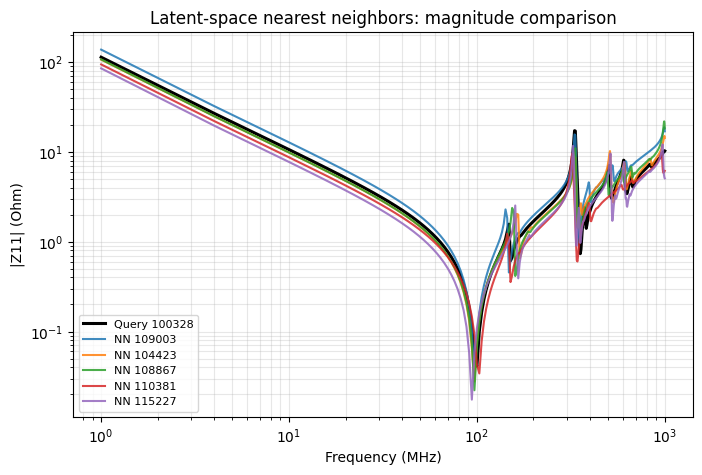

Saved: ../../Results/use_latent_database_cnn_ln_phase_ld60/figures/nn_mag_query_100328_euclidean.png


In [10]:
freq_mhz = freq_hz / 1e6

def plot_query_neighbors_magnitude(ds, query_sid, nn_sids, save_path=None):
    plt.figure(figsize=(8, 5))

    # query
    q_row = get_row_from_sid(query_sid)
    q_x = ds.impedance_data[q_row].cpu().numpy()
    q_mag = np.exp(q_x[0, :])   # ln|Z| -> |Z|
    plt.loglog(freq_mhz, q_mag, color="black", linewidth=2.2, label=f"Query {query_sid}")

    # neighbors
    for sid in nn_sids:
        row = get_row_from_sid(int(sid))
        x = ds.impedance_data[row].cpu().numpy()
        mag = np.exp(x[0, :])
        plt.loglog(freq_mhz, mag, linewidth=1.5, alpha=0.85, label=f"NN {int(sid)}")

    plt.xlabel("Frequency (MHz)")
    plt.ylabel("|Z11| (Ohm)")
    plt.title("Latent-space nearest neighbors: magnitude comparison")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=8)

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

fig_path = os.path.join(FIG_DIR, f"nn_mag_query_{query_sid}_{metric}.png")
plot_query_neighbors_magnitude(ds_full, query_sid, nn_sids, save_path=fig_path)
print("Saved:", fig_path)

# Cell 11 - Plot phase of query and neighbors

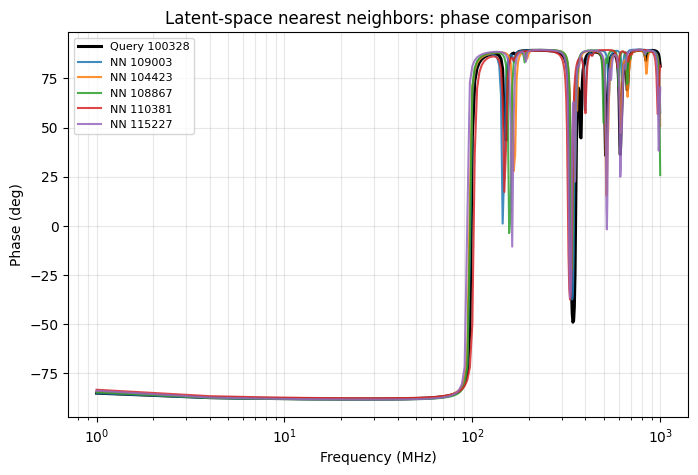

Saved: ../../Results/use_latent_database_cnn_ln_phase_ld60/figures/nn_phase_query_100328_euclidean.png


In [11]:
def plot_query_neighbors_phase(ds, query_sid, nn_sids, save_path=None):
    plt.figure(figsize=(8, 5))

    # query
    q_row = get_row_from_sid(query_sid)
    q_x = ds.impedance_data[q_row].cpu().numpy()
    q_phase = np.degrees(q_x[1, :])
    plt.semilogx(freq_mhz, q_phase, color="black", linewidth=2.2, label=f"Query {query_sid}")

    # neighbors
    for sid in nn_sids:
        row = get_row_from_sid(int(sid))
        x = ds.impedance_data[row].cpu().numpy()
        ph = np.degrees(x[1, :])
        plt.semilogx(freq_mhz, ph, linewidth=1.5, alpha=0.85, label=f"NN {int(sid)}")

    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Phase (deg)")
    plt.title("Latent-space nearest neighbors: phase comparison")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize=8)

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

fig_path = os.path.join(FIG_DIR, f"nn_phase_query_{query_sid}_{metric}.png")
plot_query_neighbors_phase(ds_full, query_sid, nn_sids, save_path=fig_path)
print("Saved:", fig_path)

# Cell 12 - Compare distance metrics for the same query

In [12]:
query_sid = 100328
k = 5

for metric in ["euclidean", "cosine", "normalized"]:
    print("\n" + "="*60)
    print("Metric:", metric)

    query_row, nn_rows, nn_sids, nn_dist = nearest_neighbors_by_sid(
        query_sid=query_sid,
        k=k,
        metric=metric
    )

    print("Query SID:", query_sid)
    for r, sid, dist in zip(nn_rows, nn_sids, nn_dist):
        print(f"  row={int(r):5d} | SID={int(sid)} | distance={float(dist):.6f}")


Metric: euclidean
Query SID: 100328
  row= 9003 | SID=109003 | distance=5.317965
  row= 4423 | SID=104423 | distance=5.361255
  row= 8867 | SID=108867 | distance=5.381074
  row=10381 | SID=110381 | distance=5.835713
  row=15227 | SID=115227 | distance=6.023512

Metric: cosine
Query SID: 100328
  row= 9003 | SID=109003 | distance=0.096457
  row= 8867 | SID=108867 | distance=0.102377
  row= 4423 | SID=104423 | distance=0.106997
  row=10381 | SID=110381 | distance=0.127171
  row= 5107 | SID=105107 | distance=0.132173

Metric: normalized
Query SID: 100328
  row= 9003 | SID=109003 | distance=3.601430
  row= 8867 | SID=108867 | distance=3.820562
  row= 4423 | SID=104423 | distance=3.864504
  row=10381 | SID=110381 | distance=4.139314
  row= 5107 | SID=105107 | distance=4.170047


# Cell - 12a Helper to compare one query for one metric

In [13]:
def phase_mae_deg(query_phase_rad, nn_phase_rad):
    """
    Mean absolute phase error in degrees with wrap-around handling.
    """
    diff = query_phase_rad - nn_phase_rad
    diff = (diff + np.pi) % (2 * np.pi) - np.pi
    return float(np.mean(np.abs(np.degrees(diff))))


def compare_metric_for_query(query_sid, metric="euclidean", k=5):
    """
    For one query sample:
    1) retrieve k nearest neighbors using chosen latent-space metric
    2) compute average magnitude MAE in dB
    3) compute average phase MAE in degrees

    Returns:
        dict with summary numbers for this query
    """
    query_row, nn_rows, nn_sids, nn_dist = nearest_neighbors_by_sid(
        query_sid=query_sid,
        k=k,
        metric=metric
    )

    # Query curve
    q_x = ds_full.impedance_data[query_row].cpu().numpy()
    q_mag = np.exp(q_x[0, :])   # ln|Z| -> |Z|
    q_phase = q_x[1, :]         # rad
    q_db = 20.0 * np.log10(q_mag + 1e-12)

    mae_db_list = []
    mae_phase_list = []

    for sid in nn_sids:
        row = get_row_from_sid(int(sid))
        x = ds_full.impedance_data[row].cpu().numpy()

        nn_mag = np.exp(x[0, :])
        nn_phase = x[1, :]
        nn_db = 20.0 * np.log10(nn_mag + 1e-12)

        mae_db = float(np.mean(np.abs(q_db - nn_db)))
        mae_phase = phase_mae_deg(q_phase, nn_phase)

        mae_db_list.append(mae_db)
        mae_phase_list.append(mae_phase)

    return {
        "query_sid": int(query_sid),
        "metric": metric,
        "k": int(k),
        "avg_neighbor_mae_db": float(np.mean(mae_db_list)),
        "avg_neighbor_phase_mae_deg": float(np.mean(mae_phase_list)),
    }

# Cell - 12b Run comparison on multiple random queries

In [14]:
np.random.seed(42)

N_QUERY = 1000
K_NN = 5
metrics_to_test = ["euclidean", "cosine", "normalized"]

# choose random valid query SIDs from full latent database
query_sids = np.random.choice(SID.astype(int), size=N_QUERY, replace=False)

print("Random query SIDs:")
print(query_sids.tolist())

results = []

for metric in metrics_to_test:
    print(f"\nRunning metric: {metric}")
    for qsid in query_sids:
        out = compare_metric_for_query(
            query_sid=int(qsid),
            metric=metric,
            k=K_NN
        )
        results.append(out)

metric_df = pd.DataFrame(results)
print("\nDone.")
print("Result table shape:", metric_df.shape)
metric_df.head(15)

Random query SIDs:
[110650, 102041, 108668, 101114, 113902, 111963, 111072, 103002, 119771, 108115, 103525, 107879, 116441, 116296, 112566, 105252, 119393, 116796, 108094, 100322, 109923, 107459, 119024, 117553, 109119, 116421, 116060, 110120, 119055, 103649, 103941, 117880, 116675, 112630, 111443, 112157, 113835, 103434, 118739, 117407, 115440, 110406, 106517, 100971, 116487, 119730, 113137, 103669, 115983, 104058, 114976, 115698, 113829, 113419, 100960, 117744, 109864, 111263, 115782, 117196, 107554, 110498, 117059, 117928, 107085, 114753, 104519, 103024, 112121, 118494, 105483, 101419, 106209, 110742, 116143, 117617, 114568, 100980, 102783, 107713, 111518, 108600, 111640, 118830, 112562, 112751, 106384, 104807, 106195, 110648, 107567, 116397, 117524, 101346, 113124, 112673, 115455, 114001, 118621, 102119, 115304, 104309, 104484, 111013, 104770, 102712, 112186, 116615, 110947, 102545, 112619, 109851, 104410, 119647, 112344, 112407, 109610, 110718, 107571, 103570, 108602, 103559, 1049

,query_sid,metric,k,avg_neighbor_mae_db,avg_neighbor_phase_mae_deg
0,110650,euclidean,5,2.268644,7.048031
1,102041,euclidean,5,2.696055,9.978902
2,108668,euclidean,5,2.894986,7.201021
3,101114,euclidean,5,3.261912,7.723561
4,113902,euclidean,5,2.201065,10.589810
5,111963,euclidean,5,2.709780,8.044156
6,111072,euclidean,5,2.113153,5.968660
7,103002,euclidean,5,4.246585,8.648159
8,119771,euclidean,5,3.187861,14.548328
9,108115,euclidean,5,3.592310,10.360576


In [15]:
# Cell 12b-extra — Inspect one query and its 5 nearest neighbors (fixed)

def plot_query_and_neighbors_by_sid(query_sid, metric="euclidean", k=5, freq_hz=None):
    """
    For one query simu_index:
    1) retrieve k nearest neighbors in latent space
    2) plot magnitude comparison
    3) plot phase comparison
    4) print per-neighbor mag/phase MAE
    """

    if freq_hz is None:
        if "freq_hz" in globals():
            freq_hz_local = freq_hz
        elif hasattr(ds_full, "freq_hz"):
            freq_hz_local = ds_full.freq_hz.cpu().numpy()
        else:
            raise ValueError("freq_hz not available. Please pass freq_hz explicitly.")
    else:
        freq_hz_local = freq_hz

    freq_mhz = np.asarray(freq_hz_local) / 1e6

    # query latent neighbors
    query_row, nn_rows, nn_sids, nn_dist = nearest_neighbors_by_sid(
        query_sid=query_sid,
        k=k,
        metric=metric
    )

    # query curve
    q_x = ds_full.impedance_data[query_row].cpu().numpy()
    q_mag = np.exp(q_x[0, :])                 # ln|Z| -> |Z|
    q_phase_deg = np.degrees(q_x[1, :])      # rad -> deg
    q_db = 20.0 * np.log10(q_mag + 1e-12)

    print(f"Query SID: {int(query_sid)}")
    print(f"Metric   : {metric}")
    print(f"Row idx  : {query_row}")

    print("\nNearest neighbors:")
    for r, sid, dist in zip(nn_rows, nn_sids, nn_dist):
        print(f"  row={int(r):5d} | SID={int(sid)} | latent_distance={float(dist):.6f}")

    print("\nPer-neighbor waveform errors:")

    # -------------------------
    # Magnitude figure
    # -------------------------
    fig_mag, ax_mag = plt.subplots(figsize=(8, 5))
    ax_mag.loglog(freq_mhz, q_mag, color="black", linewidth=2.2, label=f"Query {int(query_sid)}")

    # -------------------------
    # Phase figure
    # -------------------------
    fig_phase, ax_phase = plt.subplots(figsize=(8, 5))
    ax_phase.semilogx(freq_mhz, q_phase_deg, color="black", linewidth=2.2, label=f"Query {int(query_sid)}")

    for r, sid, dist in zip(nn_rows, nn_sids, nn_dist):
        x = ds_full.impedance_data[r].cpu().numpy()

        nn_mag = np.exp(x[0, :])
        nn_phase_deg = np.degrees(x[1, :])
        nn_db = 20.0 * np.log10(nn_mag + 1e-12)

        mag_mae_db = float(np.mean(np.abs(q_db - nn_db)))
        phase_mae = float(phase_mae_deg(np.radians(q_phase_deg), np.radians(nn_phase_deg)))

        print(
            f"  SID={int(sid)} | latent_distance={float(dist):.6f} "
            f"| mag_MAE={mag_mae_db:.6f} dB | phase_MAE={phase_mae:.6f} deg"
        )

        ax_mag.loglog(freq_mhz, nn_mag, linewidth=1.5, alpha=0.85, label=f"NN {int(sid)}")
        ax_phase.semilogx(freq_mhz, nn_phase_deg, linewidth=1.5, alpha=0.85, label=f"NN {int(sid)}")
    # -------------------------
    # Magnitude plot
    # -------------------------
    ax_mag.set_xlabel("Frequency (MHz)")
    ax_mag.set_ylabel("|Z11| (Ohm)")
    ax_mag.set_title(f"Nearest neighbors by {metric} — magnitude")
    ax_mag.grid(True, which="both", alpha=0.3)
    ax_mag.legend(fontsize=8)

    # -------------------------
    # Phase plot
    # -------------------------
    ax_phase.set_xlabel("Frequency (MHz)")
    ax_phase.set_ylabel("Phase (deg)")
    ax_phase.set_title(f"Nearest neighbors by {metric} — phase")
    ax_phase.grid(True, which="both", alpha=0.3)
    ax_phase.legend(fontsize=8)

    # IMPORTANT: show AFTER everything is set
    fig_mag.tight_layout()
    fig_phase.tight_layout()

    plt.show()

Query SID: 119771
Metric   : euclidean
Row idx  : 19771

Nearest neighbors:
  row= 9298 | SID=109298 | latent_distance=5.555661
  row=16220 | SID=116220 | latent_distance=6.565904
  row=11222 | SID=111222 | latent_distance=6.995631
  row=15049 | SID=115049 | latent_distance=7.729874
  row= 4807 | SID=104807 | latent_distance=8.053382

Per-neighbor waveform errors:
  SID=109298 | latent_distance=5.555661 | mag_MAE=3.302684 dB | phase_MAE=11.124653 deg
  SID=116220 | latent_distance=6.565904 | mag_MAE=2.297959 dB | phase_MAE=12.621867 deg
  SID=111222 | latent_distance=6.995631 | mag_MAE=2.698179 dB | phase_MAE=14.781521 deg
  SID=115049 | latent_distance=7.729874 | mag_MAE=4.592474 dB | phase_MAE=17.284496 deg
  SID=104807 | latent_distance=8.053382 | mag_MAE=3.048009 dB | phase_MAE=16.929100 deg


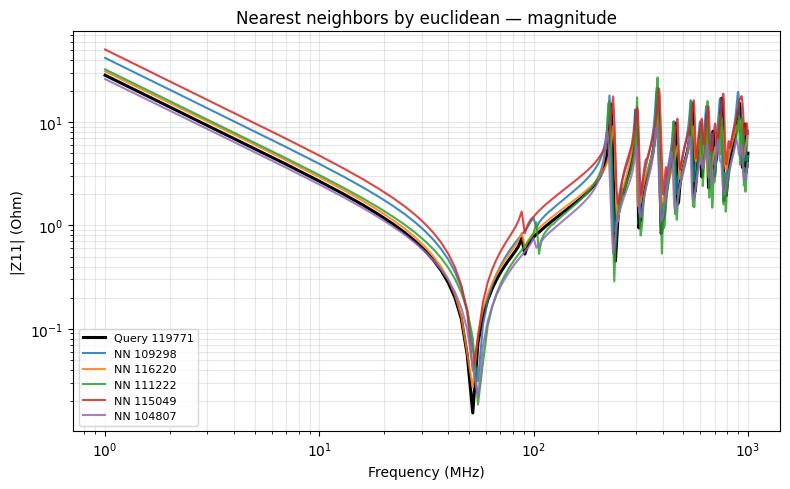

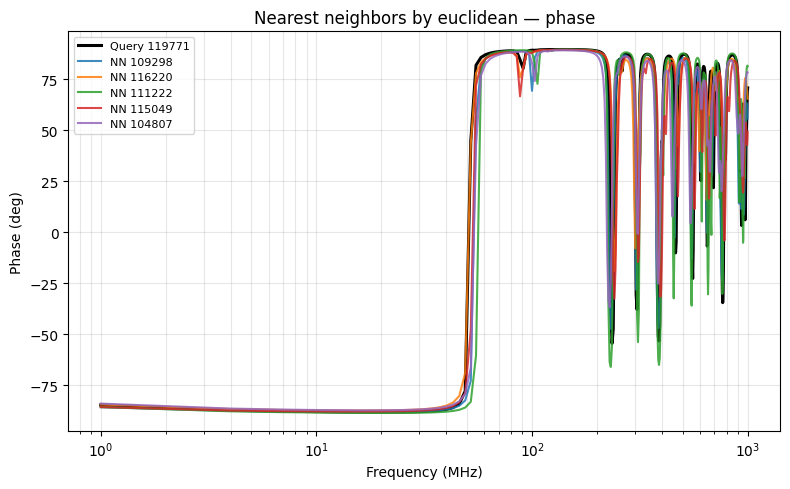

In [16]:
# Example run
query_sid = 119771
metric = "euclidean"   # "euclidean", "cosine", or "normalized"
k = 5

plot_query_and_neighbors_by_sid(query_sid=query_sid, metric=metric, k=k, freq_hz=freq_hz)

Why the phase difference is larger

Even when magnitude looks reasonably close, phase can differ more because phase is much more sensitive to small frequency shifts.

In the plots, the neighbors have:

similar overall magnitude trend
similar resonance count
but slightly shifted resonance locations

That causes:

magnitude MAE to stay moderate
phase MAE to increase a lot

Because near a resonance, phase changes very sharply. A small horizontal shift in frequency can create a large vertical phase difference.

Also phase is circular, so dips and wraps around sharp transitions make the difference look larger.

# Cell - 12c Cleaner summary table

In [17]:
summary_clean = (
    metric_df
    .groupby("metric")[["avg_neighbor_mae_db", "avg_neighbor_phase_mae_deg"]]
    .mean()
    .sort_values("avg_neighbor_mae_db")
)

print("Average neighbor similarity by metric:")
summary_clean

Average neighbor similarity by metric:


,avg_neighbor_mae_db,avg_neighbor_phase_mae_deg
metric,,
euclidean,2.559700,8.240919
cosine,2.642644,8.258478
normalized,2.744116,8.182029


# Cell - 12d Bar plot for easier visual comparison

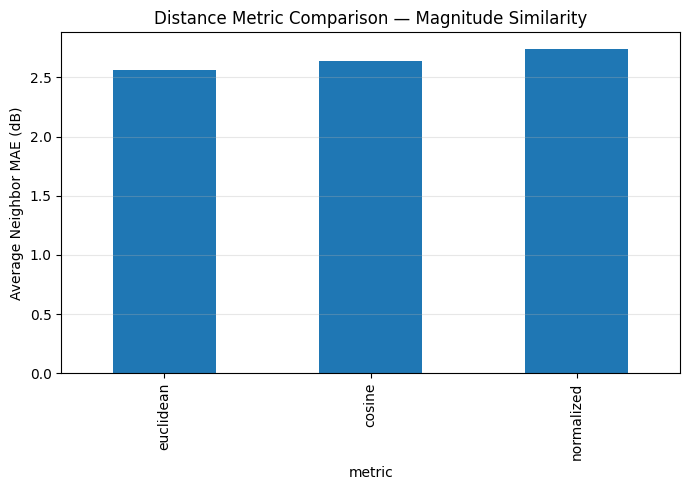

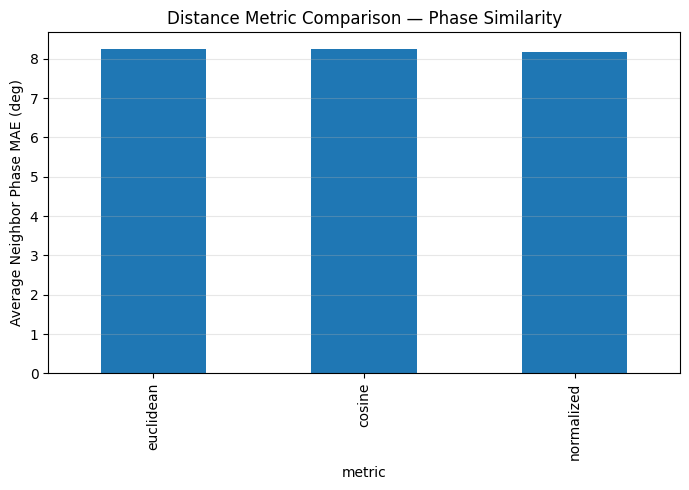

In [18]:
plt.figure(figsize=(7, 5))
summary_clean["avg_neighbor_mae_db"].plot(kind="bar")
plt.ylabel("Average Neighbor MAE (dB)")
plt.title("Distance Metric Comparison — Magnitude Similarity")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
summary_clean["avg_neighbor_phase_mae_deg"].plot(kind="bar")
plt.ylabel("Average Neighbor Phase MAE (deg)")
plt.title("Distance Metric Comparison — Phase Similarity")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Density Vs Reconstruction Errors

# Cell 13 - Reconstruction helper setup

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

ckpt = torch.load(RUN_CFG["checkpoint_path"], map_location="cpu")

model = CNNAutoencoder(latent_dim=RUN_CFG["latent_dim"])
model.load_state_dict(ckpt["model_state"])
model.to(device)
model.eval()

stats = {k: v.to(device) for k, v in ckpt["stats"].items()}

def normalize_batch_ln_phase(x: torch.Tensor, stats: dict) -> torch.Tensor:
    x = x.clone()
    x[:, 0, :] = (x[:, 0, :] - stats["ch0_mean"]) / (stats["ch0_std"] + 1e-6)
    x[:, 1, :] = (x[:, 1, :] - stats["ch1_mean"]) / (stats["ch1_std"] + 1e-6)
    return x

def denormalize_batch_ln_phase(y_norm: torch.Tensor, stats: dict) -> torch.Tensor:
    y = y_norm.clone()
    y[:, 0, :] = y[:, 0, :] * (stats["ch0_std"] + 1e-6) + stats["ch0_mean"]
    y[:, 1, :] = y[:, 1, :] * (stats["ch1_std"] + 1e-6) + stats["ch1_mean"]
    return y

Using device: cuda


/tmp/ipykernel_235296/1146571494.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(RUN_CFG["checkpoint_path"], map_location="cpu")


# Cell 14 - Compute per-sample reconstruction error on full 20k

In [41]:
from torch.utils.data import DataLoader

loader_full = DataLoader(
    ds_full,
    batch_size=RUN_CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

@torch.no_grad()
def compute_reconstruction_error_full(model, loader, stats, device):
    per_sample_mae_db = []

    for x, _, _ in loader:
        x = x.to(device)
        x_norm = normalize_batch_ln_phase(x, stats)
        y_norm, _ = model(x_norm)
        y = denormalize_batch_ln_phase(y_norm, stats)

        x_ln = x[:, 0, :].cpu().numpy()
        y_ln = y[:, 0, :].cpu().numpy()

        x_mag = np.exp(x_ln)
        y_mag = np.exp(y_ln)

        x_db = 20.0 * np.log10(x_mag + 1e-12)
        y_db = 20.0 * np.log10(y_mag + 1e-12)

        batch_mae_db = np.mean(np.abs(x_db - y_db), axis=1)   # one value per sample
        per_sample_mae_db.append(batch_mae_db)

    return np.concatenate(per_sample_mae_db)

recon_mae_db = compute_reconstruction_error_full(model, loader_full, stats, device)

print("Per-sample reconstruction error ready.")
print("Shape:", recon_mae_db.shape)
print("Mean :", float(recon_mae_db.mean()))
print("Min  :", float(recon_mae_db.min()))
print("Max  :", float(recon_mae_db.max()))

Per-sample reconstruction error ready.
Shape: (20000,)
Mean : 0.2526134252548218
Min  : 0.08343555778265
Max  : 1.4180909395217896


# Cell 15 - Compute latent-space density

In [42]:
def compute_knn_density(Z, k=10, metric="euclidean"):
    Z_used = get_latent_matrix(metric=metric)

    nn = NearestNeighbors(
        n_neighbors=k+1,   # includes self
        metric="cosine" if metric == "cosine" else "euclidean"
    )
    nn.fit(Z_used)

    distances, indices = nn.kneighbors(Z_used)

    # skip self-distance at [:, 0]
    neighbor_dist = distances[:, 1:]
    mean_knn_dist = neighbor_dist.mean(axis=1)

    density = 1.0 / (mean_knn_dist + 1e-12)
    return mean_knn_dist, density

mean_knn_dist, density = compute_knn_density(Z, k=10, metric="euclidean")

print("Density computed.")
print("mean_knn_dist shape:", mean_knn_dist.shape)
print("density shape      :", density.shape)

Density computed.
mean_knn_dist shape: (20000,)
density shape      : (20000,)


# Cell 16 - Density vs reconstruction error

In [43]:
corr_density_error = np.corrcoef(density, recon_mae_db)[0, 1]
print("Correlation(density, recon_error):", float(corr_density_error))

Correlation(density, recon_error): -0.5305418700841866


# Cell 17 - Binned density analysis

Average reconstruction MAE by density bin:
density_bin_label
Bin1 [0.0717, 0.1390]    0.360161
Bin2 [0.1390, 0.1560]    0.277132
Bin3 [0.1560, 0.1710]    0.238676
Bin4 [0.1710, 0.1910]    0.211094
Bin5 [0.1910, 0.3920]    0.176003
Name: recon_mae_db, dtype: float32


/tmp/ipykernel_235296/3331861360.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  density_grouped = analysis_df.groupby("density_bin_label")["recon_mae_db"].mean()
/tmp/ipykernel_235296/3331861360.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = analysis_df.groupby("density_bin_label").size()


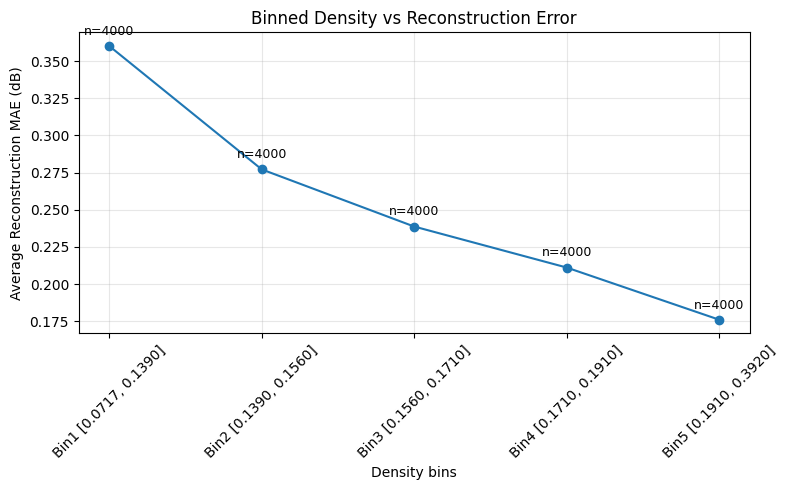

In [45]:
analysis_df = pd.DataFrame({
    "simu_index": SID.astype(int),
    "density": density,
    "mean_knn_dist": mean_knn_dist,
    "recon_mae_db": recon_mae_db,
})

# --- Create quantile bins ---
density_bins = pd.qcut(analysis_df["density"], 5, duplicates="drop")
analysis_df["density_bin"] = density_bins

# --- Create labeled bins: Bin1, Bin2, ... ---
bin_categories = analysis_df["density_bin"].cat.categories

bin_labels = {
    cat: f"Bin{i+1} [{cat.left:.4f}, {cat.right:.4f}]"
    for i, cat in enumerate(bin_categories)
}

analysis_df["density_bin_label"] = analysis_df["density_bin"].map(bin_labels)

# --- Ensure correct order ---
analysis_df["density_bin_label"] = pd.Categorical(
    analysis_df["density_bin_label"],
    categories=list(bin_labels.values()),
    ordered=True
)

# --- Group using labeled bins ---
density_grouped = analysis_df.groupby("density_bin_label")["recon_mae_db"].mean()
bin_counts = analysis_df.groupby("density_bin_label").size()

print("Average reconstruction MAE by density bin:")
print(density_grouped)

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(density_grouped.index, density_grouped.values, marker="o")
plt.xticks(rotation=45)
plt.xlabel("Density bins")
plt.ylabel("Average Reconstruction MAE (dB)")
plt.title("Binned Density vs Reconstruction Error")
plt.grid(True, alpha=0.3)

# add sample count above each point
for i, (x_label, y_val) in enumerate(zip(density_grouped.index, density_grouped.values)):
    count = int(bin_counts.loc[x_label])
    plt.annotate(
        f"n={count}",
        xy=(i, y_val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [46]:
print (bin_counts)

density_bin_label
Bin1 [0.0717, 0.1390]    4000
Bin2 [0.1390, 0.1560]    4000
Bin3 [0.1560, 0.1710]    4000
Bin4 [0.1710, 0.1910]    4000
Bin5 [0.1910, 0.3920]    4000
dtype: int64


I used quantile-based binning (pd.qcut), which ensures each bin contains approximately the same number of samples. This allows a fair comparison of reconstruction error across different density regions without bias from unequal sample sizes.

# Cell 18 - Save phase-3 analysis table

In [47]:
analysis_csv_path = os.path.join(RESULTS_DIR, "phase3_density_reconstruction_analysis.csv")
analysis_df.to_csv(analysis_csv_path, index=False)

print("Saved analysis table to:")
print(analysis_csv_path)

Saved analysis table to:
../../Results/use_latent_database_cnn_ln_phase_ld60/phase3_density_reconstruction_analysis.csv


## Phase 3 summary

This notebook provides:

- query by `simu_index`
- nearest-neighbor retrieval in latent space
- comparison of distance metrics:
  - Euclidean
  - cosine
  - normalized Euclidean
- latent-space density estimation
- correlation between latent-space density and reconstruction error

These steps support:
- latent-space validation,
- database retrieval,
- distance metric development,
- and sample-density analysis for later targeted fine-tuning.

# Phase 3b — Targeted Fine-Tuning

This section compares:

- the original baseline CNN AE checkpoint,
- a model fine-tuned on 1000 random samples,
- a model fine-tuned on the top 1000 highest-error samples.

## Goal
Test whether targeted sample selection improves reconstruction more effectively than random selection.

# Cell 19 - Select targeted and random sample sets

In [25]:
# -----------------------------
# Select fine-tuning subsets
# -----------------------------
N_SELECT = 1000
RANDOM_SEED = 42

# targeted = highest reconstruction error
top_samples = analysis_df.sort_values("recon_mae_db", ascending=False).head(N_SELECT).copy()

# random baseline subset
random_samples = analysis_df.sample(n=N_SELECT, random_state=RANDOM_SEED).copy()

print("Targeted subset shape:", top_samples.shape)
print("Random subset shape  :", random_samples.shape)

print("\nTop targeted samples:")
print(top_samples[["simu_index", "recon_mae_db", "density", "mean_knn_dist"]].head())

print("\nRandom samples:")
print(random_samples[["simu_index", "recon_mae_db", "density", "mean_knn_dist"]].head())

Targeted subset shape: (1000, 6)
Random subset shape  : (1000, 6)

Top targeted samples:
       simu_index  recon_mae_db   density  mean_knn_dist
11028      111028      1.418091  0.112467       8.891526
666        100666      1.348020  0.134143       7.454749
13658      113658      1.300668  0.103827       9.631401
2749       102749      1.299611  0.117360       8.520785
6456       106456      1.289976  0.114056       8.767603

Random samples:
       simu_index  recon_mae_db   density  mean_knn_dist
10650      110650      0.207533  0.182906       5.467285
2041       102041      0.434238  0.167462       5.971510
8668       108668      0.233586  0.143471       6.970046
1114       101114      0.244257  0.141492       7.067550
13902      113902      0.297154  0.142479       7.018595


# Cell 20 - Map simu_index to dataset row index

In [28]:
# -----------------------------
# Build simu_index -> row mapping
# -----------------------------
sid_full = np.array([int(ds_full[i][2]) for i in range(len(ds_full))])
sid_to_row_full = {sid: i for i, sid in enumerate(sid_full)}

def sid_series_to_rows(sid_series):
    rows = []
    for s in sid_series.tolist():
        s = int(s)
        if s not in sid_to_row_full:
            raise ValueError(f"simu_index {s} not found in ds_full")
        rows.append(sid_to_row_full[s])
    return rows

targeted_rows = sid_series_to_rows(top_samples["simu_index"])
random_rows   = sid_series_to_rows(random_samples["simu_index"])

print("Targeted rows:", len(targeted_rows))
print("Random rows  :", len(random_rows))

Targeted rows: 1000
Random rows  : 1000


# Cell 21 - Build fine-tuning DataLoaders

In [31]:
from torch.utils.data import DataLoader, Subset

# -----------------------------
# Fine-tuning DataLoaders
# -----------------------------
FT_BATCH_SIZE = 128

targeted_loader = DataLoader(
    Subset(ds_full, targeted_rows),
    batch_size=FT_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

random_loader = DataLoader(
    Subset(ds_full, random_rows),
    batch_size=FT_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

print("targeted_loader batches:", len(targeted_loader))
print("random_loader batches  :", len(random_loader))

targeted_loader batches: 8
random_loader batches  : 8


# Cell 22 - Load baseline checkpoint and define loss

In [32]:
# -----------------------------
# Load baseline checkpoint
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

ckpt = torch.load(RUN_CFG["checkpoint_path"], map_location="cpu")

baseline_model = CNNAutoencoder(latent_dim=RUN_CFG["latent_dim"])
baseline_model.load_state_dict(ckpt["model_state"])
baseline_model.to(device)
baseline_model.eval()

stats = {k: v.to(device) for k, v in ckpt["stats"].items()}

print("Baseline checkpoint loaded.")
print("Checkpoint path:", RUN_CFG["checkpoint_path"])

Using device: cuda
Baseline checkpoint loaded.
Checkpoint path: ../../checkpoints/cnn_ae_ln_phase_mse_N14000_ld60_lr0.0003_ep500.pt


/tmp/ipykernel_211806/655211171.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(RUN_CFG["checkpoint_path"], map_location="cpu")


# Cell 23 - Evaluation helper on any DataLoader

In [34]:
# -----------------------------
# Evaluation helper
# -----------------------------
@torch.no_grad()
def evaluate_model_mae_db(model, loader, stats, device):
    model.eval()
    per_sample_mae_db = []

    for x, _, _ in loader:
        x = x.to(device)

        x_norm = normalize_batch_ln_phase(x, stats)
        y_norm, _ = model(x_norm)
        y = denormalize_batch_ln_phase(y_norm, stats)

        x_ln = x[:, 0, :].detach().cpu().numpy()
        y_ln = y[:, 0, :].detach().cpu().numpy()

        x_mag = np.exp(x_ln)
        y_mag = np.exp(y_ln)

        x_db = 20.0 * np.log10(x_mag + 1e-12)
        y_db = 20.0 * np.log10(y_mag + 1e-12)

        batch_mae_db = np.mean(np.abs(x_db - y_db), axis=1)
        per_sample_mae_db.append(batch_mae_db)

    per_sample_mae_db = np.concatenate(per_sample_mae_db)
    return float(per_sample_mae_db.mean()), per_sample_mae_db

# Cell 24 - Build evaluation loaders

In [35]:
# -----------------------------
# Evaluation loaders
# -----------------------------
EVAL_BATCH_SIZE = 256

full_eval_loader = DataLoader(
    ds_full,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

targeted_eval_loader = DataLoader(
    Subset(ds_full, targeted_rows),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

random_eval_loader = DataLoader(
    Subset(ds_full, random_rows),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("Evaluation loaders ready.")

Evaluation loaders ready.


# Cell 25 - Baseline metrics before fine-tuning

In [38]:
# -----------------------------
# Baseline evaluation
# -----------------------------
baseline_full_mae, _ = evaluate_model_mae_db(baseline_model, full_eval_loader, stats, device)
baseline_targeted_mae, _ = evaluate_model_mae_db(baseline_model, targeted_eval_loader, stats, device)
baseline_random_mae, _ = evaluate_model_mae_db(baseline_model, random_eval_loader, stats, device)

print("Baseline metrics")
print("-" * 40)
print(f"Full 20k MAE (dB)     : {baseline_full_mae:.6f}")
print(f"Targeted subset MAE    : {baseline_targeted_mae:.6f}")
print(f"Random subset MAE      : {baseline_random_mae:.6f}")

Baseline metrics
----------------------------------------
Full 20k MAE (dB)     : 0.252613
Targeted subset MAE    : 0.589314
Random subset MAE      : 0.243731


# Cell 26 - Fine-tuning helper

In [39]:
# -----------------------------
# Fine-tuning helper
# -----------------------------
import copy
import torch.nn as nn

def finetune_model_from_checkpoint(
    ckpt,
    train_loader,
    stats,
    device,
    latent_dim=60,
    lr=1e-4,
    epochs=10,
    log_every=1
):
    model = CNNAutoencoder(latent_dim=latent_dim)
    model.load_state_dict(ckpt["model_state"])
    model.to(device)
    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"epoch_loss": []}

    for epoch in range(1, epochs + 1):
        running_loss = 0.0
        n_batches = 0

        for x, _, _ in train_loader:
            x = x.to(device)

            x_norm = normalize_batch_ln_phase(x, stats)

            optimizer.zero_grad()
            y_norm, _ = model(x_norm)
            loss = criterion(y_norm, x_norm)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        epoch_loss = running_loss / max(n_batches, 1)
        history["epoch_loss"].append(epoch_loss)

        if epoch % log_every == 0:
            print(f"Epoch {epoch:02d}/{epochs} | train loss = {epoch_loss:.6f}")

    model.eval()
    return model, history

# Cell 29 - Fine-tune on random samples

In [40]:
# -----------------------------
# Fine-tune on RANDOM subset
# -----------------------------
FT_LR = 1e-4
FT_EPOCHS = 10

print("Fine-tuning on RANDOM subset")
random_ft_model, random_ft_history = finetune_model_from_checkpoint(
    ckpt=ckpt,
    train_loader=random_loader,
    stats=stats,
    device=device,
    latent_dim=RUN_CFG["latent_dim"],
    lr=FT_LR,
    epochs=FT_EPOCHS,
    log_every=1,
)

Fine-tuning on RANDOM subset
Epoch 01/10 | train loss = 0.002547
Epoch 02/10 | train loss = 0.002240
Epoch 03/10 | train loss = 0.002122
Epoch 04/10 | train loss = 0.002064
Epoch 05/10 | train loss = 0.002012
Epoch 06/10 | train loss = 0.001979
Epoch 07/10 | train loss = 0.001958
Epoch 08/10 | train loss = 0.001939
Epoch 09/10 | train loss = 0.001921
Epoch 10/10 | train loss = 0.001901


# Cell 28 - Fine-tune on targeted high-error samples

In [41]:
# -----------------------------
# Fine-tune on TARGETED subset
# -----------------------------
print("Fine-tuning on TARGETED high-error subset")
targeted_ft_model, targeted_ft_history = finetune_model_from_checkpoint(
    ckpt=ckpt,
    train_loader=targeted_loader,
    stats=stats,
    device=device,
    latent_dim=RUN_CFG["latent_dim"],
    lr=FT_LR,
    epochs=FT_EPOCHS,
    log_every=1,
)

Fine-tuning on TARGETED high-error subset
Epoch 01/10 | train loss = 0.013309
Epoch 02/10 | train loss = 0.012701
Epoch 03/10 | train loss = 0.012337
Epoch 04/10 | train loss = 0.012056
Epoch 05/10 | train loss = 0.011870
Epoch 06/10 | train loss = 0.011696
Epoch 07/10 | train loss = 0.011552
Epoch 08/10 | train loss = 0.011382
Epoch 09/10 | train loss = 0.011280
Epoch 10/10 | train loss = 0.011177


# Cell 29 - Evaluate all three models

In [42]:
# -----------------------------
# Evaluate baseline vs fine-tuned models
# -----------------------------
# Baseline
baseline_full_mae, _ = evaluate_model_mae_db(baseline_model, full_eval_loader, stats, device)
baseline_targeted_mae, _ = evaluate_model_mae_db(baseline_model, targeted_eval_loader, stats, device)
baseline_random_mae, _ = evaluate_model_mae_db(baseline_model, random_eval_loader, stats, device)

# Random fine-tuned
randomft_full_mae, _ = evaluate_model_mae_db(random_ft_model, full_eval_loader, stats, device)
randomft_targeted_mae, _ = evaluate_model_mae_db(random_ft_model, targeted_eval_loader, stats, device)
randomft_random_mae, _ = evaluate_model_mae_db(random_ft_model, random_eval_loader, stats, device)

# Targeted fine-tuned
targetedft_full_mae, _ = evaluate_model_mae_db(targeted_ft_model, full_eval_loader, stats, device)
targetedft_targeted_mae, _ = evaluate_model_mae_db(targeted_ft_model, targeted_eval_loader, stats, device)
targetedft_random_mae, _ = evaluate_model_mae_db(targeted_ft_model, random_eval_loader, stats, device)

comparison_df = pd.DataFrame([
    ["baseline", "full_20k", baseline_full_mae],
    ["baseline", "targeted_subset", baseline_targeted_mae],
    ["baseline", "random_subset", baseline_random_mae],

    ["random_finetune", "full_20k", randomft_full_mae],
    ["random_finetune", "targeted_subset", randomft_targeted_mae],
    ["random_finetune", "random_subset", randomft_random_mae],

    ["targeted_finetune", "full_20k", targetedft_full_mae],
    ["targeted_finetune", "targeted_subset", targetedft_targeted_mae],
    ["targeted_finetune", "random_subset", targetedft_random_mae],
], columns=["model", "eval_set", "mae_db"])

comparison_df

,model,eval_set,mae_db
0,baseline,full_20k,0.252613
1,baseline,targeted_subset,0.589314
2,baseline,random_subset,0.243731
3,random_finetune,full_20k,0.244698
4,random_finetune,targeted_subset,0.585247
5,random_finetune,random_subset,0.222656
6,targeted_finetune,full_20k,0.274523
7,targeted_finetune,targeted_subset,0.548131
8,targeted_finetune,random_subset,0.267016


# Cell 30 - Pivot view for easier reading

In [43]:
pivot_df = comparison_df.pivot(index="eval_set", columns="model", values="mae_db")
print("Comparison table (MAE in dB):")
pivot_df

Comparison table (MAE in dB):


model,baseline,random_finetune,targeted_finetune
eval_set,,,
full_20k,0.252613,0.244698,0.274523
random_subset,0.243731,0.222656,0.267016
targeted_subset,0.589314,0.585247,0.548131


# Cell 31 - Improvement relative to baseline

In [44]:
improve_df = pivot_df.copy()

if "baseline" in improve_df.columns:
    for col in improve_df.columns:
        if col != "baseline":
            improve_df[f"{col}_improvement_vs_baseline"] = improve_df["baseline"] - improve_df[col]

print("Improvement relative to baseline (positive = better):")
improve_df

Improvement relative to baseline (positive = better):


model,baseline,random_finetune,targeted_finetune,random_finetune_improvement_vs_baseline,targeted_finetune_improvement_vs_baseline
eval_set,,,,,
full_20k,0.252613,0.244698,0.274523,0.007915,-0.021909
random_subset,0.243731,0.222656,0.267016,0.021075,-0.023285
targeted_subset,0.589314,0.585247,0.548131,0.004067,0.041183


# Cell 32 - Plot comparison

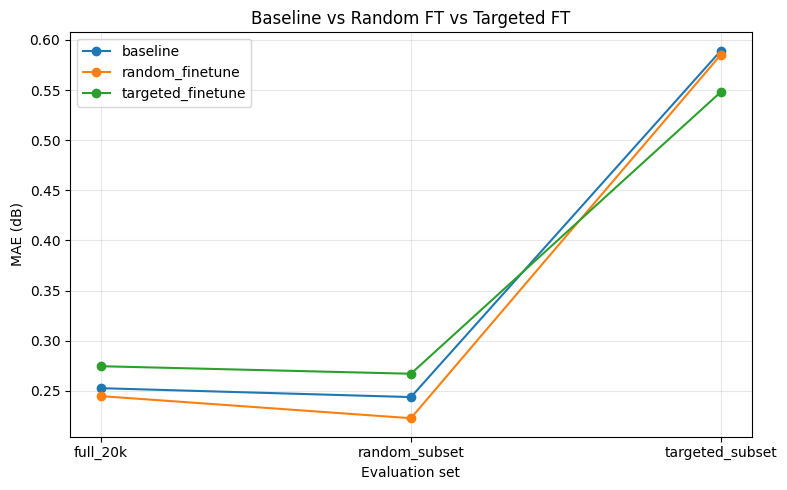

In [45]:
plt.figure(figsize=(8, 5))

for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], marker="o", label=col)

plt.ylabel("MAE (dB)")
plt.xlabel("Evaluation set")
plt.title("Baseline vs Random FT vs Targeted FT")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
ft_results_csv = os.path.join(RESULTS_DIR, "targeted_finetuning_comparison.csv")
comparison_df.to_csv(ft_results_csv, index=False)

ft_pivot_csv = os.path.join(RESULTS_DIR, "targeted_finetuning_comparison_pivot.csv")
pivot_df.to_csv(ft_pivot_csv)

print("Saved:")
print(ft_results_csv)
print(ft_pivot_csv)

In [ ]:
random_ft_ckpt_path = os.path.join(RESULTS_DIR, "cnn_ln_phase_ld60_random_finetuned.pt")
targeted_ft_ckpt_path = os.path.join(RESULTS_DIR, "cnn_ln_phase_ld60_targeted_finetuned.pt")

torch.save({
    "model_state": random_ft_model.state_dict(),
    "stats": {k: v.detach().cpu() for k, v in stats.items()},
    "source_checkpoint": RUN_CFG["checkpoint_path"],
    "finetune_type": "random",
    "epochs": FT_EPOCHS,
    "lr": FT_LR,
    "n_select": N_SELECT,
}, random_ft_ckpt_path)

torch.save({
    "model_state": targeted_ft_model.state_dict(),
    "stats": {k: v.detach().cpu() for k, v in stats.items()},
    "source_checkpoint": RUN_CFG["checkpoint_path"],
    "finetune_type": "targeted_high_error",
    "epochs": FT_EPOCHS,
    "lr": FT_LR,
    "n_select": N_SELECT,
}, targeted_ft_ckpt_path)

print("Saved checkpoints:")
print(random_ft_ckpt_path)
print(targeted_ft_ckpt_path)

# Hard Samples vs Latent Space

Top 10% highest reconstruction error = hard samples as quantile 0.90

Fraction of hard samples by density bin:
density_bin_label
Bin1 [0.0717, 0.1390]    0.31900
Bin2 [0.1390, 0.1560]    0.10725
Bin3 [0.1560, 0.1710]    0.04925
Bin4 [0.1710, 0.1910]    0.02250
Bin5 [0.1910, 0.3920]    0.00200
Name: is_hard, dtype: float64


/tmp/ipykernel_147039/292629642.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hard_fraction_by_bin = analysis_tmp.groupby("density_bin_label")["is_hard"].mean()


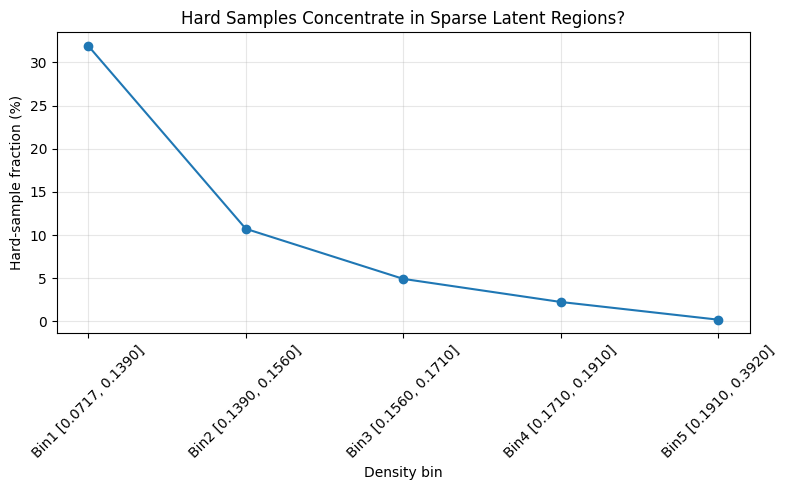

In [59]:
analysis_tmp = analysis_df.copy()

hard_thr = analysis_tmp["recon_mae_db"].quantile(0.90)
analysis_tmp["is_hard"] = analysis_tmp["recon_mae_db"] >= hard_thr

hard_fraction_by_bin = analysis_tmp.groupby("density_bin_label")["is_hard"].mean()

print("Fraction of hard samples by density bin:")
print(hard_fraction_by_bin)

plt.figure(figsize=(8, 5))
plt.plot(hard_fraction_by_bin.index, 100 * hard_fraction_by_bin.values, marker="o")
plt.xticks(rotation=45)
plt.ylabel("Hard-sample fraction (%)")
plt.xlabel("Density bin")
plt.title("Hard Samples Concentrate in Sparse Latent Regions?")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A strong inverse relationship is observed between latent-space density and reconstruction difficulty. 
Approximately 31.9% of samples in the lowest-density bin belong to the top 10% highest reconstruction error, 
while this fraction drops to only 0.2% in the highest-density bin. 
This indicates that reconstruction errors are concentrated in sparse regions of the latent space.

# Checking how the hard samples look like and what geometry parameters value they are holding?

In [60]:
# -----------------------------
# Pick a few hard samples
# -----------------------------
N_SHOW = 5

hard_samples = analysis_df.sort_values("recon_mae_db", ascending=False).head(N_SHOW).copy()

print("Selected hard samples:")
print(hard_samples[["simu_index", "recon_mae_db", "density"]])

Selected hard samples:
       simu_index  recon_mae_db   density
11028      111028      1.418091  0.112467
666        100666      1.348020  0.134143
13658      113658      1.300668  0.103827
2749       102749      1.299611  0.117360
6456       106456      1.289976  0.114056


In [61]:
# -----------------------------
# Map simu_index → dataset row
# -----------------------------
hard_rows = sid_series_to_rows(hard_samples["simu_index"])

print("Hard rows:", hard_rows)

Hard rows: [11028, 666, 13658, 2749, 6456]


In [68]:
# -----------------------------
# Plot mag + phase for hard samples
# -----------------------------


@torch.no_grad()
def plot_hard_samples(model, rows, ds_full, stats, device, n_show=5, freq_hz=None):
   model.eval()

   # real frequency axis in MHz
   if freq_hz is None:
       raise ValueError("Please provide freq_hz so the x-axis matches the dataset.")
   freq_mhz = np.asarray(freq_hz) / 1e6

   for row in rows[:n_show]:
       x, _, sid = ds_full[row]
       x = x.unsqueeze(0).to(device)

       # forward pass
       x_norm = normalize_batch_ln_phase(x, stats)
       y_norm, _ = model(x_norm)
       y = denormalize_batch_ln_phase(y_norm, stats)

       # to numpy
       x_np = x.squeeze(0).cpu().numpy()
       y_np = y.squeeze(0).cpu().numpy()

       # channel 0 is ln|Z|  --> convert back to |Z| in Ohm
       x_mag = np.exp(x_np[0])
       y_mag = np.exp(y_np[0])

       # channel 1 is phase in radians --> convert to degrees
       x_phase = np.degrees(x_np[1])
       y_phase = np.degrees(y_np[1])

       plt.figure(figsize=(6, 8))

       # -------------------------
       # Magnitude: log x, log y
       # -------------------------
       plt.subplot(2, 1, 1)
       plt.loglog(freq_mhz, x_mag, color="black", linewidth=2, label="Z11 Sim.")
       plt.loglog(freq_mhz, y_mag, color="red", linestyle="--", linewidth=2, label="Z11 Pred.")
       plt.ylabel("|Z11| (Ohm)")
       plt.title(f"simu_{int(sid)}")
       plt.grid(True, which="both", alpha=0.3)
       plt.legend()

       # -------------------------
       # Phase: log x, linear y
       # -------------------------
       plt.subplot(2, 1, 2)
       plt.semilogx(freq_mhz, x_phase, color="black", linewidth=2, label="Phase Sim.")
       plt.semilogx(freq_mhz, y_phase, color="red", linestyle="--", linewidth=2, label="Phase Pred.")
       plt.xlabel("Frequency (MHz)")
       plt.ylabel("Phase (°)")
       plt.ylim([-180, 180])
       plt.grid(True, which="both", alpha=0.3)
       plt.legend()

       plt.tight_layout()
       plt.show()

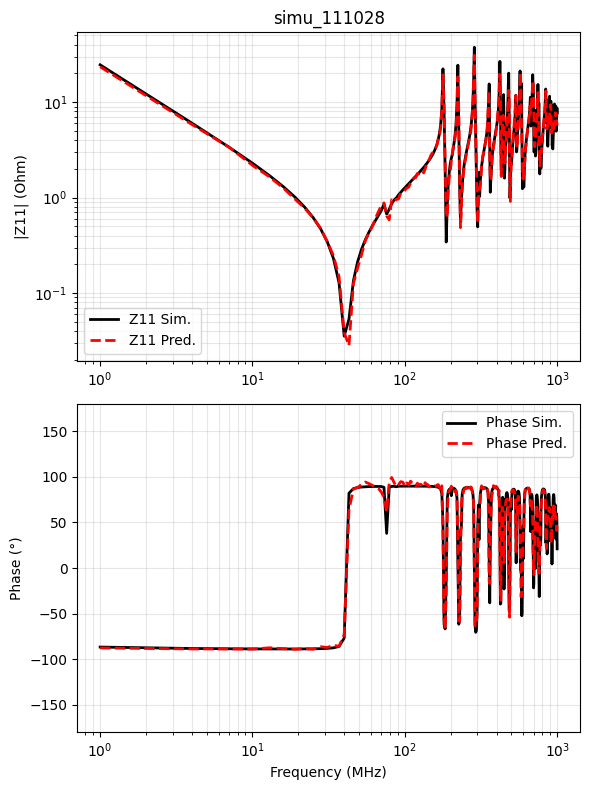

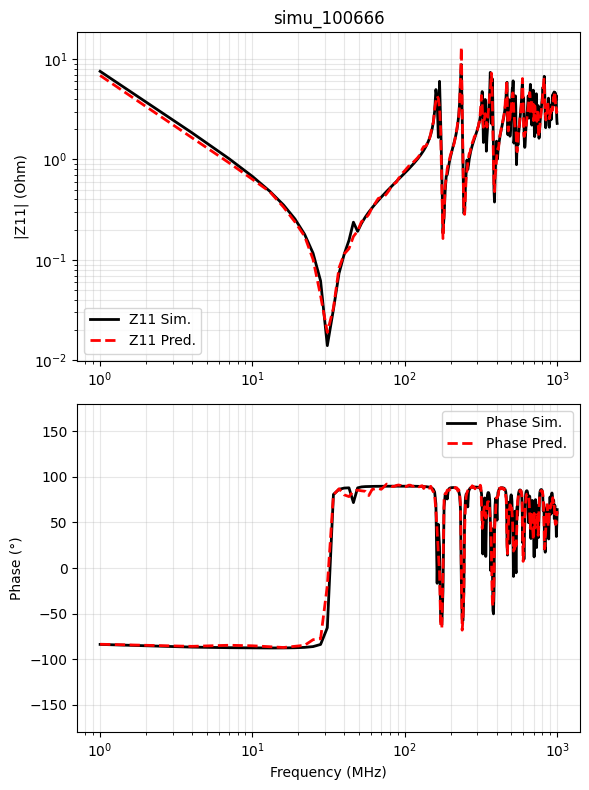

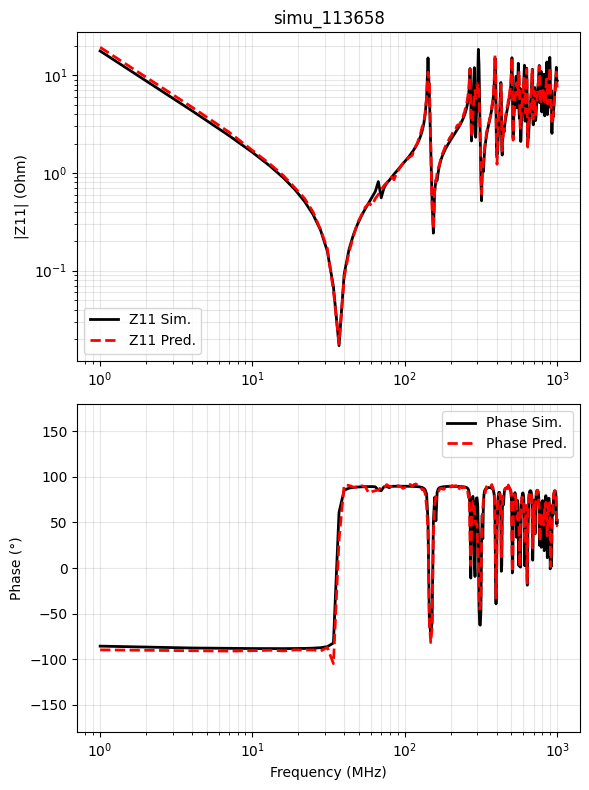

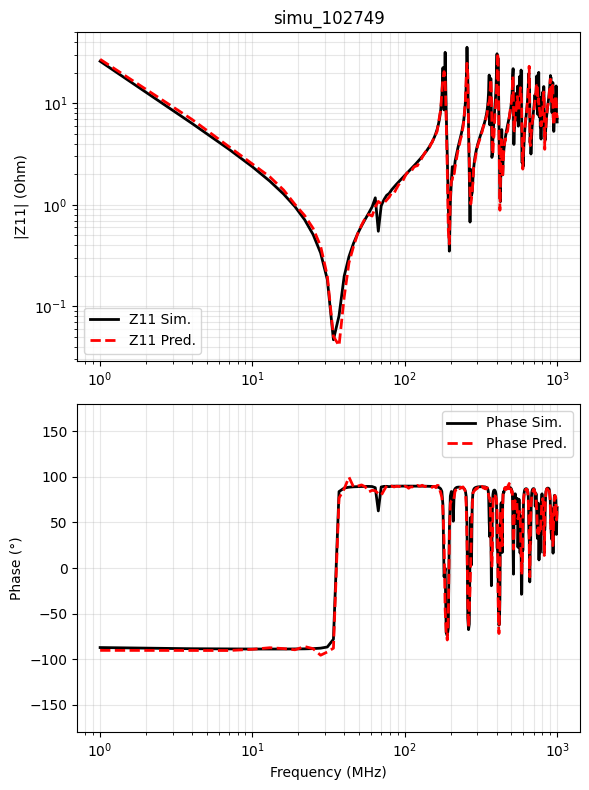

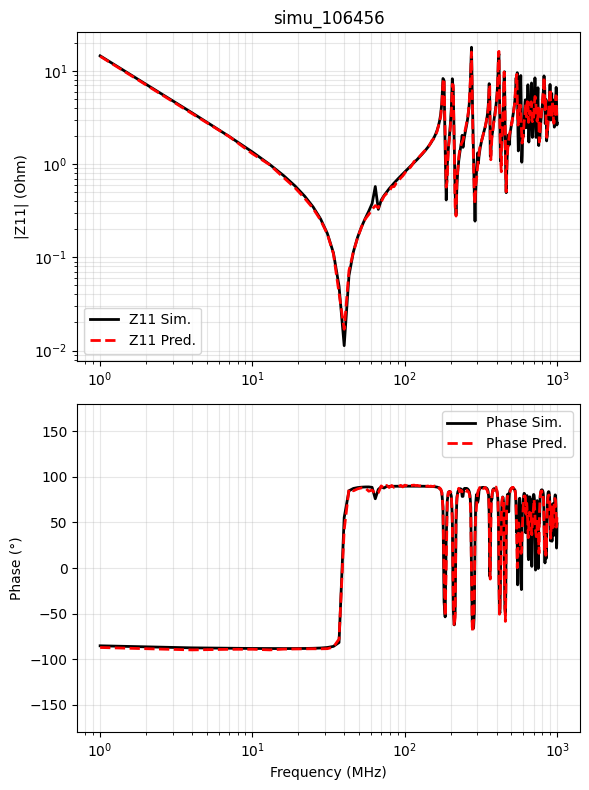

In [70]:
plot_hard_samples(baseline_model, hard_rows, ds_full, stats, device, n_show=N_SHOW, freq_hz=freq_hz)

In [71]:
# -----------------------------
# Show geometry parameters of hard samples
# -----------------------------
param_df = pd.read_csv(RUN_CFG["csv_file"])

hard_geo = param_df[param_df["simu_index"].isin(hard_samples["simu_index"])]

print("Geometry parameters of hard samples:")
display(hard_geo)

Geometry parameters of hard samples:


,simu_index,TDIEL,TMET,XWIDTH,YWIDTH,CONDUCTIVITY,PERMITTIVITY,LOSSTANGENT,A1_VIARADIUS,A1_ANTIPADRADIUS,A1_VIAPITCH,A1_XCENTER,A1_YCENTER,A2_VIARADIUS,A2_ANTIPADRADIUS,A2_VIAPITCH,A2_XCENTER,A2_YCENTER
666,100666,26.9223,3.51804,16289.90,17045.3,55873100.0,4.56813,0.005988,7.0,17.0,40.0,15350.0,450.0,6.0,22.0,40.0,16150.0,4450.0
2749,102749,76.6637,3.30399,14254.90,14627.0,45931100.0,5.05489,0.006020,5.0,20.0,40.0,13900.0,13550.0,7.0,23.0,40.0,2250.0,6700.0
6456,106456,38.1174,1.07245,13370.70,15349.2,54349100.0,4.56745,0.006308,8.0,15.0,40.0,12450.0,700.0,6.0,18.0,40.0,500.0,14050.0
11028,111028,60.1360,2.99803,16565.90,13284.5,48069500.0,3.96346,0.005498,8.0,15.0,40.0,750.0,12400.0,9.0,18.0,40.0,13550.0,8000.0
13658,113658,44.8049,2.75011,9492.51,17910.2,47440800.0,5.31307,0.006671,6.0,19.0,40.0,500.0,17550.0,7.0,20.0,40.0,8950.0,5450.0
